Diffusion models are generative models that create new data (like images). At a high level, diffusion models start with pure noise (like a static TV screen) and gradually remove noise step by step until a clear image forms, guided by your text prompt. This process makes them powerful for creative tasks like AI art, image editing, and even video generation.

AI Image Generation using Diffusion Models

First, let’s get the tools we need. We’ll use Hugging Face Diffusers, PyTorch, and a few utility libraries. Here’s how to install them if you are not using Google Colab:

In [ ]:
pip install diffusers transformers accelerate torch torchvision safetensors

Here’s a breakdown of all these libraries:

* diffusers: the main library for diffusion models.
* transformers: provides text processing (turning words into embeddings).
* accelerate: helps run the model efficiently on different devices (CPU, GPU, or Apple Silicon).
* torch & torchvision: core deep learning framework powering Stable Diffusion.
* safetensors: safer model weights format.

Step 1: Set Up the Environment

Now, let’s prepare the pipeline for AI Image Generation using Diffusion Models. We’ll write code in a way that works on a GPU, Apple M1/M2 chip, or just a CPU:

In [ ]:
import torch
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id, torch_dtype=torch.float16 if device=="cuda" else torch.float32
)

pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)

if device == "cuda":
    pipe = pipe.to(device)
    pipe.enable_attention_slicing()
else:
    pipe.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Here’s what’s happening here:

1. We load Stable Diffusion v1.5, a widely used model for text-to-image.
2. We detect your hardware, such as CUDA (NVIDIA GPU), MPS (Apple Silicon), or CPU.
3. The Euler Ancestral sampler is set, a fast and high-quality sampling method.
4. On the GPU, we enable attention slicing to save memory.

If you’re on CPU, it will still work, just slower.

Step 2: Write Your First Prompt

Now comes the prompting part. It means telling the model what to generate:

In [ ]:
prompt = "ultra-detailed portrait of a red fox wearing a tiny scarf, cinematic lighting, 35mm"
negative_prompt = "blurry, lowres, jpeg artifacts, extra fingers, text, watermark"

The prompt here means what you want in the image. And the negative_prompt means what you don’t wish to (helps avoid weird results). Always be descriptive! Adding details like lighting, style, or lens type can significantly enhance image quality.

Step 3: Generate the Image

Now, let’s create the image with some key parameters:

In [ ]:
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,   # 20–35 is a good range
    guidance_scale=7.5,       # 5–9 usually
    height=512,
    width=512,
    generator=torch.Generator(device=device).manual_seed(42)
).images[0]

image.save("generated_image.png")

  0%|          | 0/30 [00:00<?, ?it/s]

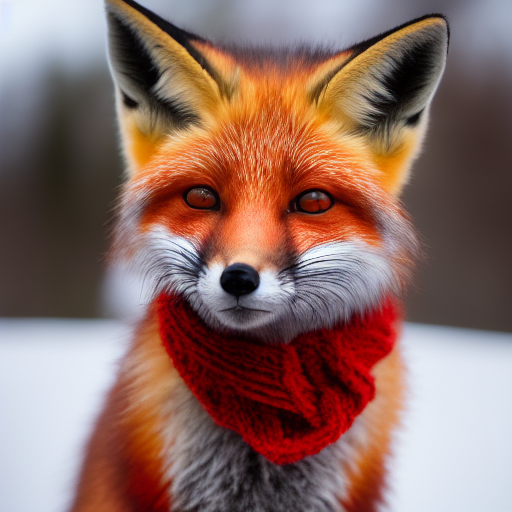

Here are some key parameters we used:

1. num_inference_steps: how many steps the model takes to denoise the image. More steps = more detail, but slower.
2. guidance_scale: how strongly the model follows your text prompt. Lower (3–5) = more creative, sometimes unexpected.
3. manual_seed(42): ensures reproducibility. Same seed + prompt = same image. Change the seed for fresh variations.

Final Words

So, with just a few lines of Python, you can turn text into stunning visuals, experiment with styles, and push the limits of imagination. The key is to keep experimenting with prompts, parameters, and samplers until you discover the results you love.